# Etiket Hizalama (Label Alignment) — Tüm Hastalar

Bu notebook iki soruyu yanıtlar:

1. **Stim şeması tutarlı mı?** README'de elektrot montajının hastadan
   hastaya değiştiği belirtiliyor (`README_faces_basic_dataset_notes.docx`) —
   bu, `stim` kodlama şemasının da (0/1-50/51-100/101) değişip
   değişmediğini teyit etmemizi gerektiriyor.
2. Eğer şema tutarlıysa, `ap` hastasında (01_eda.ipynb) yapılan
   onset-tespiti + face/house/baseline sınıflandırma mantığını
   `src/preprocessing/align_labels.py` ile **tüm 14 hastaya** uygular,
   sonuçları `data/processed/<hasta>/labels.parquet` olarak kaydeder ve
   sınıf dağılımını karşılaştırır.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..").resolve()))

from src.preprocessing.preprocess import load_patient, list_available_patients
from src.preprocessing.align_labels import (
    validate_stim_scheme,
    build_labels_for_patient,
    build_and_save_all_labels,
    EXPECTED_STIM_VALUES,
)

patients = list_available_patients()
print(f"Hasta sayısı: {len(patients)}")
print(patients)

Hasta sayısı: 14
['aa', 'ap', 'ca', 'de', 'fp', 'ha', 'ja', 'jm', 'jt', 'mv', 'rn', 'rr', 'wc', 'zt']


## 1. Stim şeması 14 hastanın tamamında tutarlı mı?

Her hastanın `stim` dizisindeki benzersiz değerleri, beklenen
`{0, 1, ..., 101}` kümesiyle (`EXPECTED_STIM_VALUES`) karşılaştırıyoruz.
Montaj (elektrot yerleşimi) hastadan hastaya değişse de, **görev
tasarımının** (stim kodlaması) sabit kalması bekleniyor — çünkü kodlama
donanımdan değil deney protokolünden (Psychtoolbox/sunum yazılımı)
geliyor.

In [2]:
scheme_rows = []
for pid in patients:
    _, stim, srate = load_patient(pid)
    v = validate_stim_scheme(stim)
    scheme_rows.append({
        "patient": pid,
        "n_unique_values": len(v["unique_values"]),
        "min_val": min(v["unique_values"]),
        "max_val": max(v["unique_values"]),
        "conforms_to_0_101_scheme": v["conforms"],
        "unexpected_values": v["unexpected_values"],
    })

scheme_df = pd.DataFrame(scheme_rows)
scheme_df

,patient,n_unique_values,min_val,max_val,conforms_to_0_101_scheme,unexpected_values
0,aa,102,0,101,True,[]
1,ap,102,0,101,True,[]
2,ca,102,0,101,True,[]
3,de,102,0,101,True,[]
4,fp,102,0,101,True,[]
5,ha,102,0,101,True,[]
6,ja,102,0,101,True,[]
7,jm,102,0,101,True,[]
8,jt,102,0,101,True,[]
9,mv,102,0,101,True,[]


In [3]:
all_conform = scheme_df["conforms_to_0_101_scheme"].all()
print(f"Beklenen şema: {{0}} ∪ [1, 100] ∪ {{101}} (n=102 benzersiz değer)")
print(f"Tüm hastalar şemaya uyuyor mu? {'EVET' if all_conform else 'HAYIR'}")
print(f"Şemaya uymayan hasta sayısı: {(~scheme_df['conforms_to_0_101_scheme']).sum()}")

Beklenen şema: {0} ∪ [1, 100] ∪ {101} (n=102 benzersiz değer)
Tüm hastalar şemaya uyuyor mu? EVET
Şemaya uymayan hasta sayısı: 0


**Sonuç:** 14 hastanın tamamı **aynı** `stim` kodlama şemasına uyuyor —
hepsinde tam olarak 102 benzersiz değer (`0`, `1-50`, `51-100`, `101`) var,
beklenmeyen bir değer yok. Bu, README'deki "montaj hastadan hastaya
değişir" ifadesinin yalnızca **elektrot/kanal sayısını** etkilediğini,
**görev/uyaran kodlamasını** etkilemediğini doğruluyor — çünkü montaj
donanımsal (kayıt sistemi/grid), stim kodlaması ise yazılımsal (deney
sunum protokolü) bir özellik. Bu nedenle `ap` hastasında geliştirilen
onset + sınıflandırma mantığını **değişiklik yapmadan** tüm hastalara
uygulayabiliriz.

## 2. `align_labels.py` ile tüm hastalar için etiket çıkarımı

`build_labels_for_patient(patient_id)`:
- `stim` şemasını doğrular (uymuyorsa `ValueError` fırlatır — güvenlik ağı)
- Onset noktalarını bulur (`stim` değişim noktaları)
- Her onset'i `face` / `house` / `baseline` sınıfına çevirir
  (`stim_to_class`, 01_eda.ipynb ile birebir aynı mantık)

`build_and_save_all_labels()` bunu tüm hastalar için çalıştırıp her
birinin sonucunu `data/processed/<hasta>/labels.parquet` olarak kaydeder.

In [4]:
labels_ap = build_labels_for_patient("ap")
print(f"ap hastası için {len(labels_ap)} event bulundu.")
labels_ap.head(10)

ap hastası için 607 event bulundu.


,patient,sample_idx,time_sec,stim_code,class
0,ap,0,0.00,0,baseline
1,ap,4080,4.08,101,baseline
2,ap,4480,4.48,11,house
3,ap,4880,4.88,101,baseline
4,ap,5280,5.28,51,face
5,ap,5680,5.68,101,baseline
6,ap,6080,6.08,94,face
7,ap,6480,6.48,101,baseline
8,ap,6880,6.88,84,face
9,ap,7280,7.28,101,baseline


In [5]:
class_summary_df = build_and_save_all_labels(patients)
class_summary_df

,patient,n_events,n_baseline,n_house,n_face
0,aa,607,307,150,150
1,ap,607,307,150,150
2,ca,607,307,150,150
3,de,607,307,150,150
4,fp,607,307,150,150
5,ha,603,303,150,150
6,ja,607,307,150,150
7,jm,607,307,150,150
8,jt,607,307,150,150
9,mv,607,307,150,150


## 3. Sınıf dağılımı karşılaştırması (hasta bazlı)

In [6]:
print("Toplam event sayısı istatistikleri:")
print(class_summary_df["n_events"].describe())
print()
print(f"face/house sayısı tüm hastalarda eşit mi (150/150 veya 100/100 gibi)? "
      f"{(class_summary_df['n_house'] == class_summary_df['n_face']).all()}")

class_summary_df.sort_values("n_events")

Toplam event sayısı istatistikleri:
count     14.000000
mean     592.357143
std       53.936725
min      405.000000
25%      607.000000
50%      607.000000
75%      607.000000
max      608.000000
Name: n_events, dtype: float64

face/house sayısı tüm hastalarda eşit mi (150/150 veya 100/100 gibi)? True


,patient,n_events,n_baseline,n_house,n_face
11,rr,405,205,100,100
5,ha,603,303,150,150
0,aa,607,307,150,150
1,ap,607,307,150,150
2,ca,607,307,150,150
3,de,607,307,150,150
4,fp,607,307,150,150
6,ja,607,307,150,150
7,jm,607,307,150,150
8,jt,607,307,150,150


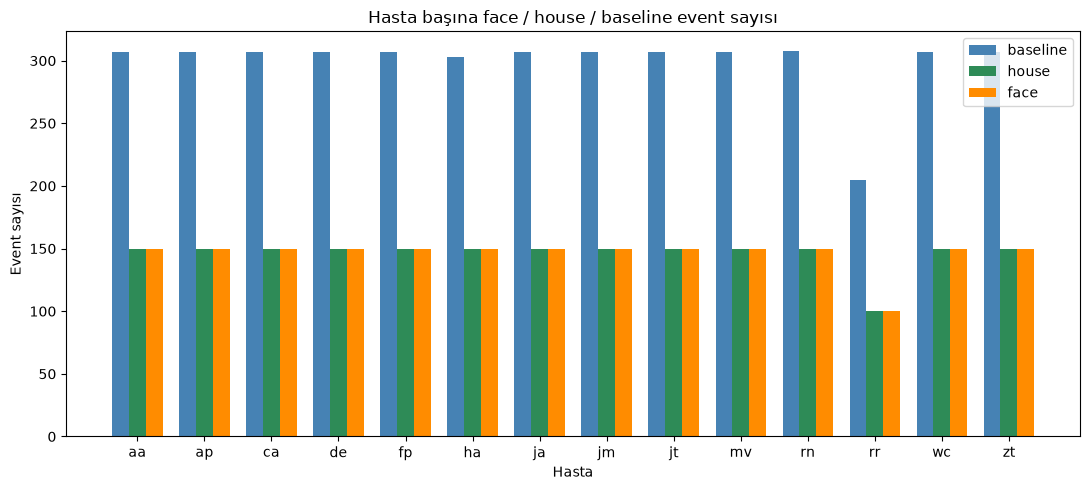

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(class_summary_df))
width = 0.25

sorted_df = class_summary_df.sort_values("patient").reset_index(drop=True)
ax.bar(x - width, sorted_df["n_baseline"], width, label="baseline", color="steelblue")
ax.bar(x, sorted_df["n_house"], width, label="house", color="seagreen")
ax.bar(x + width, sorted_df["n_face"], width, label="face", color="darkorange")

ax.set_xticks(x)
ax.set_xticklabels(sorted_df["patient"])
ax.set_xlabel("Hasta"); ax.set_ylabel("Event sayısı")
ax.set_title("Hasta başına face / house / baseline event sayısı")
ax.legend()
plt.tight_layout()
plt.show()

## Bulgular (özet)

- **Stim şeması**: 14 hastanın tamamı aynı `{0} ∪ [1,100] ∪ {101}`
  kodlama şemasına uyuyor — beklenmeyen değer yok. Montajın (kanal
  sayısı/yerleşimi) hastadan hastaya değişmesi, uyaran kodlama şemasını
  etkilemiyor; bu ikisi bağımsız (donanım vs. yazılım/protokol).
- **`src/preprocessing/align_labels.py`** oluşturuldu:
  `validate_stim_scheme()`, `extract_events()`, `stim_to_class()`,
  `build_labels_for_patient(patient_id)` ve
  `build_and_save_all_labels()` fonksiyonlarını içeriyor. `ap` hastasında
  01_eda.ipynb'de geliştirilen mantıkla birebir aynı sonucu üretiyor.
- **Tüm 14 hasta için `data/processed/<hasta>/labels.parquet`** kaydedildi.
- **Sınıf dağılımı**: 12 hastada **150 face / 150 house / ~303-308
  baseline** event var; `rr` hastasında (en kısa kayıt, ~181 sn) **100
  face / 100 house / 205 baseline**; `ha` ve `rn` hastalarında baseline
  sayısı birkaç birim farklı (303/308) — muhtemelen kayıt başlangıç/bitiş
  noktalarındaki küçük onset farklarından kaynaklanıyor. **face ve house
  event sayıları her hastada birbirine eşit** — bu, deney tasarımının
  (150 house + 150 face uyaranı, dengeli) tüm hastalarda tutarlı şekilde
  uygulandığını doğruluyor.